In [103]:
import pandas as pd

# CalificacionesP24

In [104]:
sheet_names = [
    'Calculo 1',
    'Calculo 2',
    'Estadistica CS',
    'Estadistica N',
    'Estadistica Inferencial',
    'Mate Universitaria',
    'Estadistica SL',
    'Algebra Lineal',
    'EDO',
    'Teoria de matrices'
]


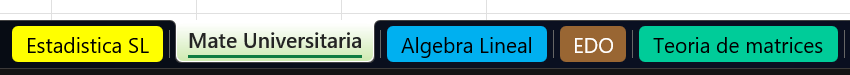

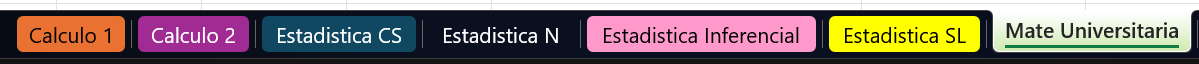

In [105]:
calificaciones = {}
for sheet in sheet_names:
    calificaciones[sheet] = pd.read_excel('data/onedrive/Archivos2024/CalificacionesP24.xlsx', sheet_name=sheet)

In [106]:
calificaciones['Mate Universitaria']

,ID,Año,Periodo,Clave,Materia,Calificación,Estatus
0,141549,2018,Otoño,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.3,APROBADA
1,148182,2021,Otoño,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,APROBADA
2,151115,2019,Otoño,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.4,REPROBADA
3,151457,2020,Otoño,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.9,APROBADA
4,151487,2020,Otoño,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,APROBADA
...,...,...,...,...,...,...,...
7790,183644,2024,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,BAJA VOLUNTARIA
7791,183662,2024,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BA,BAJA ACADEMICA
7792,183688,2024,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.4,APROBADA
7793,183711,2024,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9,APROBADA


In [107]:
# select rows where ID equals 183644
calificaciones['Mate Universitaria'].loc[calificaciones['Mate Universitaria']['ID'] == 183644]

,ID,Año,Periodo,Clave,Materia,Calificación,Estatus
7790,183644,2024,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,BAJA VOLUNTARIA


In [108]:
# select rows where ID equals 
calificaciones['Mate Universitaria'].loc[calificaciones['Mate Universitaria']['ID'] == 175199]

,ID,Año,Periodo,Clave,Materia,Calificación,Estatus
4368,175199,2021,Otoño,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.1,REPROBADA
5830,175199,2022,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,APROBADA
6018,175199,2023,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,APROBADA


hay estudiantes que salen varias veces en la misma materia!

In [109]:
calis = pd.concat(calificaciones.values(), ignore_index=True)
calificaciones = None

In [110]:
calis.loc[calis['ID'] == 175199]

,ID,Año,Periodo,Clave,Materia,Calificación,Estatus
4772,175199.0,2022,OTOÑO,MAT1022,CÁLCULO I,10,APROBADA
5677,175199.0,2023,OTOÑO,MAT1022,CÁLCULO I,10,APROBADA
10105,175199.0,2023,OTOÑO,MAT2012,CÁLCULO II,10,APROBADA
10461,175199.0,2023,PRIMAVERA,MAT2012,CÁLCULO II,10,APROBADA
19540,175199.0,2021,Otoño,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.1,REPROBADA
21002,175199.0,2022,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,APROBADA
21190,175199.0,2023,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,APROBADA
27095,175199.0,2022,PRIMAVERA,LAT2022,TEORÍA DE MATRICES,8.8,APROBADA
27110,175199.0,2023,OTOÑO,LAT2022,TEORÍA DE MATRICES,8.8,APROBADA


In [111]:
# get unique values from calis['Periodo']
unique_periods = calis['Periodo'].unique()
unique_periods

array(['OTOÑO', 'PRIMAVERA', 'VERANO', ' OTOÑO', ' OTOÑO II',
       ' PRIMAVERA', ' VERANO I', ' PRIMAVERA II', 'Otoño ', ' VERANO II'],
      dtype=object)

In [112]:
# Get where Periodo is ' OTOÑO II'
calis.loc[calis['Periodo'] == ' OTOÑO II']

,ID,Año,Periodo,Clave,Materia,Calificación,Estatus
4894,160998.0,2022,OTOÑO II,MAT1022,CÁLCULO I,5.4,REPROBADA
4895,163882.0,2022,OTOÑO II,MAT1022,CÁLCULO I,10,APROBADA
4896,164517.0,2022,OTOÑO II,MAT1022,CÁLCULO I,10,APROBADA
4897,168087.0,2022,OTOÑO II,MAT1022,CÁLCULO I,9.7,APROBADA
4898,171201.0,2022,OTOÑO II,MAT1022,CÁLCULO I,8,APROBADA
4899,171953.0,2022,OTOÑO II,MAT1022,CÁLCULO I,BV,BAJA VOLUNTARIA
4900,171974.0,2022,OTOÑO II,MAT1022,CÁLCULO I,9.6,APROBADA
4901,172954.0,2022,OTOÑO II,MAT1022,CÁLCULO I,BV,BAJA VOLUNTARIA
4902,173121.0,2022,OTOÑO II,MAT1022,CÁLCULO I,10,APROBADA
4903,173258.0,2022,OTOÑO II,MAT1022,CÁLCULO I,10,APROBADA


In [113]:
# array(['OTOÑO', 'PRIMAVERA', 'VERANO', ' OTOÑO', ' OTOÑO II',
#        ' PRIMAVERA', ' VERANO I', ' PRIMAVERA II', 'Otoño ', ' VERANO II'],
#       dtype=object)

# Normalizar periodos
period_mapping = {
    'OTOÑO': 'O',
    'PRIMAVERA': 'P',
    'VERANO': 'V',
    ' OTOÑO': 'O',
    ' OTOÑO II': 'O',
    ' PRIMAVERA': 'P',
    ' VERANO I': 'VI',
    ' PRIMAVERA II': 'P',
    'Otoño ': 'O',
    ' VERANO II': 'VII'}


calis['Periodo'] = calis['Periodo'].replace(period_mapping)

In [114]:
calis['Periodo'].unique()

array(['O', 'P', 'V', 'VI', 'VII'], dtype=object)

In [115]:
# make the ID an int if they are not NaN
idsnan = calis['ID'].isna().sum()
print(f'Number of NaN IDs: {idsnan}')

Number of NaN IDs: 1


In [116]:
# view the one with NaN IDs
calis[calis['ID'].isna()]

,ID,Año,Periodo,Clave,Materia,Calificación,Estatus
57,NaN,2018,O,MAT1022,CÁLCULO I,10,APROBADA


In [117]:
calis

,ID,Año,Periodo,Clave,Materia,Calificación,Estatus
0,156816.0,2018,O,MAT1022,CÁLCULO I,8.2,APROBADA
1,156910.0,2018,O,MAT1022,CÁLCULO I,7.8,APROBADA
2,157150.0,2018,O,MAT1022,CÁLCULO I,8.7,APROBADA
3,157496.0,2018,O,MAT1022,CÁLCULO I,7.7,APROBADA
4,157755.0,2018,O,MAT1022,CÁLCULO I,10,APROBADA
...,...,...,...,...,...,...,...
27577,168804.0,2021,P,LAT2022,TEORÍA DE MATRICES,10,APROBADA
27578,168834.0,2021,P,LAT2022,TEORÍA DE MATRICES,10,APROBADA
27579,170716.0,2021,P,LAT2022,TEORÍA DE MATRICES,9.4,APROBADA
27580,172058.0,2021,P,LAT2022,TEORÍA DE MATRICES,8.1,APROBADA


In [118]:
# replace NaN IDs with -1
calis['ID'] = calis['ID'].fillna(-1)

In [119]:
# Change type from float to int
calis['ID'] = calis['ID'].astype(int)

In [120]:
calis

,ID,Año,Periodo,Clave,Materia,Calificación,Estatus
0,156816,2018,O,MAT1022,CÁLCULO I,8.2,APROBADA
1,156910,2018,O,MAT1022,CÁLCULO I,7.8,APROBADA
2,157150,2018,O,MAT1022,CÁLCULO I,8.7,APROBADA
3,157496,2018,O,MAT1022,CÁLCULO I,7.7,APROBADA
4,157755,2018,O,MAT1022,CÁLCULO I,10,APROBADA
...,...,...,...,...,...,...,...
27577,168804,2021,P,LAT2022,TEORÍA DE MATRICES,10,APROBADA
27578,168834,2021,P,LAT2022,TEORÍA DE MATRICES,10,APROBADA
27579,170716,2021,P,LAT2022,TEORÍA DE MATRICES,9.4,APROBADA
27580,172058,2021,P,LAT2022,TEORÍA DE MATRICES,8.1,APROBADA


In [121]:
calis.loc[calis['ID'] == 175199]

,ID,Año,Periodo,Clave,Materia,Calificación,Estatus
4772,175199,2022,O,MAT1022,CÁLCULO I,10,APROBADA
5677,175199,2023,O,MAT1022,CÁLCULO I,10,APROBADA
10105,175199,2023,O,MAT2012,CÁLCULO II,10,APROBADA
10461,175199,2023,P,MAT2012,CÁLCULO II,10,APROBADA
19540,175199,2021,O,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.1,REPROBADA
21002,175199,2022,P,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,APROBADA
21190,175199,2023,O,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,APROBADA
27095,175199,2022,P,LAT2022,TEORÍA DE MATRICES,8.8,APROBADA
27110,175199,2023,O,LAT2022,TEORÍA DE MATRICES,8.8,APROBADA


# Calificaciones DMU Final

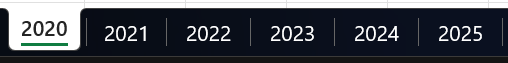

In [5]:
sheet_names = [
    '2020',
    '2021',
    '2022',
    '2023',
    '2024',
    '2025'
]

In [16]:
dmu = {}

for sheet in sheet_names:
    dmu[sheet] = pd.read_excel('data/onedrive/Archivos2024/CalificacionesDMUFinal2025.xlsx', sheet_name=sheet)
    dmu[sheet]['Year'] = sheet


In [17]:
dmu['2024']

,ID,Carrera,Periodo,Año,DMUParcial1 [Puntos totales: 40 Puntuación],DMUParcial2 [Puntos totales: 40 Puntuación],DMUParcial3 [Puntos totales: 40 Puntuación],DMUParcial4 [Puntos totales: 30 Puntuación],Resultado Total DMU [Puntos totales: hasta 150 Puntuación],Tipo_de_examen,Porcentaje,Year
0,181849,Ingeniería en Logística,P,2024,0,10,0,10,20,DMU,13.333333,2024
1,180320,Estrategias Financieras y Contaduría Pública,P,2024,20,0,0,10,30,DMU,20.000000,2024
2,181017,Administración de Empresas,P,2024,0,0,20,10,30,DMU,20.000000,2024
3,179791,Administración de Negocios Internacionales,P,2024,20,10,0,0,30,DMU,20.000000,2024
4,182132,Químico Farmacéutico Biólogo,P,2024,10,0,10,20,40,DMU,26.666667,2024
...,...,...,...,...,...,...,...,...,...,...,...,...
524,179400,NaN,P,2024,40,40,40,30,150,DMU,100.000000,2024
525,180700,Actuaría,P,2024,40,40,40,30,150,DMU,100.000000,2024
526,179422,Actuaría,P,2024,40,40,40,30,150,DMU,100.000000,2024
527,180861,NaN,P,2024,40,40,40,30,150,DMU,100.000000,2024


In [25]:
dmu_complete = pd.concat(dmu.values(), ignore_index=True)
dmu_complete

,ID,Carrera,Periodo,Año,DMUParcial1 [Puntos totales: 40 Puntuación],DMUParcial2 [Puntos totales: 40 Puntuación],DMUParcial3 [Puntos totales: 40 Puntuación],DMUParcial4 [Puntos totales: 30 Puntuación],Resultado Total DMU [Puntos totales: hasta 150 Puntuación],Tipo_de_examen,Porcentaje,Year
0,166769,Ingeniería Industrial,P,2020,30,40,20,20,110,DMU,73.333333,2020
1,162180,NaN,P,2020,10,30,30,0,70,DMU,46.666667,2020
2,162534,Ingeniería Química,P,2020,20,20,10,10,60,DMU,40.000000,2020
3,168609,Ingeniería Biomédica,P,2020,20,20,20,0,60,DMU,40.000000,2020
4,164311,Administración de Negocios Internacionales,P,2020,10,20,10,10,50,DMU,33.333333,2020
...,...,...,...,...,...,...,...,...,...,...,...,...
2782,183549,Mercadotecnia,P,2024,40,40,30,30,140,DMU,93.333333,2025
2783,172338,Física,P,2024,40,40,40,20,140,DMU,93.333333,2025
2784,177677,Administración de Empresas,P,2024,30,40,30,20,120,DMU,80.000000,2025
2785,181938,Ingeniería Industrial,P,2024,40,40,40,20,140,DMU,93.333333,2025


In [26]:
dmu = None
dmu = dmu_complete.copy()
dmu_complete = None

In [27]:
dmu

,ID,Carrera,Periodo,Año,DMUParcial1 [Puntos totales: 40 Puntuación],DMUParcial2 [Puntos totales: 40 Puntuación],DMUParcial3 [Puntos totales: 40 Puntuación],DMUParcial4 [Puntos totales: 30 Puntuación],Resultado Total DMU [Puntos totales: hasta 150 Puntuación],Tipo_de_examen,Porcentaje,Year
0,166769,Ingeniería Industrial,P,2020,30,40,20,20,110,DMU,73.333333,2020
1,162180,NaN,P,2020,10,30,30,0,70,DMU,46.666667,2020
2,162534,Ingeniería Química,P,2020,20,20,10,10,60,DMU,40.000000,2020
3,168609,Ingeniería Biomédica,P,2020,20,20,20,0,60,DMU,40.000000,2020
4,164311,Administración de Negocios Internacionales,P,2020,10,20,10,10,50,DMU,33.333333,2020
...,...,...,...,...,...,...,...,...,...,...,...,...
2782,183549,Mercadotecnia,P,2024,40,40,30,30,140,DMU,93.333333,2025
2783,172338,Física,P,2024,40,40,40,20,140,DMU,93.333333,2025
2784,177677,Administración de Empresas,P,2024,30,40,30,20,120,DMU,80.000000,2025
2785,181938,Ingeniería Industrial,P,2024,40,40,40,20,140,DMU,93.333333,2025


In [33]:
dmu.loc[dmu['ID'] == 179738]

,ID,Carrera,Periodo,Año,DMUParcial1 [Puntos totales: 40 Puntuación],DMUParcial2 [Puntos totales: 40 Puntuación],DMUParcial3 [Puntos totales: 40 Puntuación],DMUParcial4 [Puntos totales: 30 Puntuación],Resultado Total DMU [Puntos totales: hasta 150 Puntuación],Tipo_de_examen,Porcentaje,Year
2786,179738,Mercadotecnia,P,2024,40,20,40,10,110,DMU,73.333333,2025


In [36]:
dmu.loc[dmu['ID'] == 175199]

,ID,Carrera,Periodo,Año,DMUParcial1 [Puntos totales: 40 Puntuación],DMUParcial2 [Puntos totales: 40 Puntuación],DMUParcial3 [Puntos totales: 40 Puntuación],DMUParcial4 [Puntos totales: 30 Puntuación],Resultado Total DMU [Puntos totales: hasta 150 Puntuación],Tipo_de_examen,Porcentaje,Year


No todos tomaron el DMU, hay que agregar el ID y poner NaN en esos casos.

In [50]:
# get all unique IDs from calis
unique_ids_calis = calis['ID'].unique()
unique_ids_calis

array([156816., 156910., 157150., ..., 158492., 161567., 168829.],
      shape=(9771,))

In [51]:
# add them to dmu if they are not already there
for uid in unique_ids_calis:
    if uid not in dmu['ID'].values:
        dmu = pd.concat([dmu, pd.DataFrame({'ID': [uid]})], ignore_index=True)

In [52]:
dmu

,ID,Carrera,Periodo,Año,DMUParcial1 [Puntos totales: 40 Puntuación],DMUParcial2 [Puntos totales: 40 Puntuación],DMUParcial3 [Puntos totales: 40 Puntuación],DMUParcial4 [Puntos totales: 30 Puntuación],Resultado Total DMU [Puntos totales: hasta 150 Puntuación],Tipo_de_examen,Porcentaje,Year
0,166769.0,Ingeniería Industrial,P,2020.0,30.0,40.0,20.0,20,110.0,DMU,73.333333,2020
1,162180.0,NaN,P,2020.0,10.0,30.0,30.0,0,70.0,DMU,46.666667,2020
2,162534.0,Ingeniería Química,P,2020.0,20.0,20.0,10.0,10,60.0,DMU,40.000000,2020
3,168609.0,Ingeniería Biomédica,P,2020.0,20.0,20.0,20.0,0,60.0,DMU,40.000000,2020
4,164311.0,Administración de Negocios Internacionales,P,2020.0,10.0,20.0,10.0,10,50.0,DMU,33.333333,2020
...,...,...,...,...,...,...,...,...,...,...,...,...
9789,161199.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9790,157098.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9791,158492.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9792,161567.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
# view the unique values for Periodo
dmu['Periodo'].unique()

array(['P', nan], dtype=object)

In [123]:
# replace NaN IDs with -1
dmu['ID'] = calis['ID'].fillna(-1)
# Change type from float to int
dmu['ID'] = dmu['ID'].astype(int)

In [124]:
# drop the column Año
dmu = dmu.drop(columns=['Año'])

In [125]:
dmu

,ID,Carrera,Periodo,DMUParcial1 [Puntos totales: 40 Puntuación],DMUParcial2 [Puntos totales: 40 Puntuación],DMUParcial3 [Puntos totales: 40 Puntuación],DMUParcial4 [Puntos totales: 30 Puntuación],Resultado Total DMU [Puntos totales: hasta 150 Puntuación],Tipo_de_examen,Porcentaje,Year
0,156816,Ingeniería Industrial,P,30.0,40.0,20.0,20,110.0,DMU,73.333333,2020
1,156910,NaN,P,10.0,30.0,30.0,0,70.0,DMU,46.666667,2020
2,157150,Ingeniería Química,P,20.0,20.0,10.0,10,60.0,DMU,40.000000,2020
3,157496,Ingeniería Biomédica,P,20.0,20.0,20.0,0,60.0,DMU,40.000000,2020
4,157755,Administración de Negocios Internacionales,P,10.0,20.0,10.0,10,50.0,DMU,33.333333,2020
...,...,...,...,...,...,...,...,...,...,...,...
9789,175939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9790,175941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9791,175948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9792,175949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Asesorias

In [8]:
asesorias = pd.read_excel('data/onedrive/Archivos2024/Asesorias2024.xlsx')

In [18]:
asesorias

,fecha,id,carrera,semestre,profesor,materia,tema,periodo
0,2024-05-03 10:53:52,180214,Administración de Empresas,2,Ozkar Hernández Montero,Cálculo I,Aplicaciones de la integral,P
1,2024-05-02 12:01:42,179021,Física,4,Celic Teotetl Cárdenas Osorio,Ecuaciones Diferenciales Ordinarias,Edos,P
2,2024-05-02 12:00:17,177219,Estrategias Financieras y Contaduría Pública,4,Celic Teotetl Cárdenas Osorio,Estadística Para Negocios,Estadistica para negocios 2,P
3,2024-04-30 11:11:52,182618,Bioquímica Clínica,2,Daniela Rodríguez Tzompantzi,Cálculo I,Derivadas,P
4,2024-04-29 16:47:06,176657,Administración de Empresas,4,Paulino Antonio Gómez Salgado,Cálculo I,Límites de funciones,P
...,...,...,...,...,...,...,...,...
13495,2019-01-10 08:11:31,165047,Administración de Empresas,1,Efren Matlalcuatzi Rugerio,Matemáticas Universitarias,Funciones,P
13496,2019-01-10 08:10:44,166502,Ingeniería en Sistemas Computacionales,1,Gabriela López Pineda,Matemáticas Universitarias,Funciones,P
13497,2019-01-10 08:10:06,166960,Biología,1,Gabriela López Pineda,Matemáticas Universitarias,Funciones,P
13498,2019-01-10 07:18:44,162836,Ingeniería Mecánica,3,Efren Matlalcuatzi Rugerio,Cálculo II,Sucesiones y series,P


In [38]:
asesorias.loc[asesorias['id'] == 175199]

,fecha,id,carrera,semestre,profesor,materia,tema,periodo
1173,2023-12-04 11:07:41,175199,Actuaría,4,José Gerardo Ahuatzi Reyes,Cálculo II,Superficies,O
2710,2023-08-03 11:58:12,175199,Actuaría,4,José Gerardo Ahuatzi Reyes,Cálculo II,Sucesiones y series,O
2747,2023-07-11 16:35:05,175199,Banca e Inversiones,5,Ruy Alberto López Ríos,Econometría,Econometría,O
2962,2023-06-03 11:17:48,175199,Actuaría,4,José Gerardo Ahuatzi Reyes,Cálculo II,Sucesiones y series,P
3181,2023-04-13 11:25:30,175199,Actuaría,4,Ana Aleyda Oroza,Estadística Inferencial,Análisis de varianza: diferencias entre tres o...,P
3490,2023-03-13 11:12:25,175199,Actuaría,4,José Gerardo Ahuatzi Reyes,Cálculo II,Sucesiones y series,P
3667,2023-02-22 11:11:25,175199,Actuaría,4,José Gerardo Ahuatzi Reyes,Cálculo II,Sucesiones y series,P
4006,2023-01-30 11:09:29,175199,Actuaría,4,Gerardo Hernández Valdez,Cálculo II,Sucesiones y series,P
4033,2023-01-25 10:58:42,175199,Actuaría,4,José Gerardo Ahuatzi Reyes,Cálculo II,Coordenadas polares,P
4180,2023-01-03 11:23:00,175199,Actuaría,4,José Gerardo Ahuatzi Reyes,Cálculo II,Sucesiones y series,P


# EstudiantesProfesores

In [9]:
materias = pd.read_excel('data/onedrive/Archivos2024/Materias estudiantes-profesores 2019-2025 P y O.xlsx')

In [19]:
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,159167,LAR,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,22473.0
1,165277,LAD,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,22473.0
2,162781,LII,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,22473.0
3,161869,LIM,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.9,22473.0
4,164732,LMK,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,22473.0
...,...,...,...,...,...,...,...,...,...
27783,177753,LAD,2025,PRIMAVERA,0,MAT1022,CÁLCULO I,9.1,22446.0
27784,177677,LAD,2025,PRIMAVERA,0,MAT1022,CÁLCULO I,RT,22446.0
27785,176090,LNI,2025,PRIMAVERA,0,MAT1022,CÁLCULO I,2.8,22446.0
27786,181762,LIS,2025,PRIMAVERA,0,MAT1022,CÁLCULO I,8.2,22446.0


In [39]:
materias.loc[materias['CLAVEALUMNO'] == 175199]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
3173,175199,LAT,2021,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.1,23835.0
5191,175199,LDS,2023,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,NaN
6258,175199,LAT,2022,OTOÑO,0,MAT1022,CÁLCULO I,10,24827.0
14587,175199,LDS,2023,OTOÑO,0,MAT2012,CÁLCULO II,10,NaN
20218,175199,LDS,2023,OTOÑO,0,MAT1022,CÁLCULO I,10,NaN
26000,175199,LAT,2023,PRIMAVERA,0,MAT2012,CÁLCULO II,10,23874.0
27589,175199,LAT,2022,PRIMAVERA,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,23897.0


Hay NaNs porque son las revalidadas?

## CLAVEALUMNO CLAVECARRERA

In [126]:
alumnocarrera = materias[['CLAVEALUMNO', 'CLAVECARRERA']]
alumnocarrera

,CLAVEALUMNO,CLAVECARRERA
0,159167,LAR
1,165277,LAD
2,162781,LII
3,161869,LIM
4,164732,LMK
...,...,...
27783,177753,LAD
27784,177677,LAD
27785,176090,LNI
27786,181762,LIS


In [129]:
alumnocarrera.loc[alumnocarrera['CLAVEALUMNO'] == 175199]

,CLAVEALUMNO,CLAVECARRERA
3173,175199,LAT
5191,175199,LDS
6258,175199,LAT
14587,175199,LDS
20218,175199,LDS
26000,175199,LAT
27589,175199,LAT


In [130]:
# keep only unique rows
alumnocarrera = alumnocarrera.drop_duplicates()
alumnocarrera

,CLAVEALUMNO,CLAVECARRERA
0,159167,LAR
1,165277,LAD
2,162781,LII
3,161869,LIM
4,164732,LMK
...,...,...
27658,178588,LAR
27659,178629,LFB
27663,177408,LAR
27670,177959,LAR


In [131]:
alumnocarrera.loc[alumnocarrera['CLAVEALUMNO'] == 175199]

,CLAVEALUMNO,CLAVECARRERA
3173,175199,LAT
5191,175199,LDS


In [134]:
# view duplicated CLAVEALUMNO
alumnocarrera[alumnocarrera['CLAVEALUMNO'].duplicated(keep=False)].sort_values('CLAVEALUMNO')

,CLAVEALUMNO,CLAVECARRERA
4636,159437,LCN
4637,159437,LPA
6251,159723,LDS
3836,159723,LFA
2516,160003,LRT
...,...,...
13262,185560,LRIM
6002,185929,LFB
6003,185929,LNM
13173,186010,LEC


In [150]:
# we only want one CLAVEALUMNO per row, so we will creato CLAVECARRERA2, CLAVECARRERA3, etc.
alumnocarrera_pivot = alumnocarrera.pivot_table(index='CLAVEALUMNO', 
                                                columns=alumnocarrera.groupby('CLAVEALUMNO').cumcount()+1,
                                                values='CLAVECARRERA',
                                                aggfunc='first'
                                               )


In [151]:
alumnocarrera_pivot

,1,2,3
CLAVEALUMNO,,,
88493,LCN,NaN,NaN
92988,LPA,NaN,NaN
94286,LEF,NaN,NaN
111083,LFP,NaN,NaN
134718,LIS,NaN,NaN
...,...,...,...
403729,BNI,NaN,NaN
403730,BNI,NaN,NaN
403731,BNI,NaN,NaN


In [152]:
# view the column 3 where is not zero
alumnocarrera_pivot[alumnocarrera_pivot[3] != 0]

,1,2,3
CLAVEALUMNO,,,
88493,LCN,NaN,NaN
92988,LPA,NaN,NaN
94286,LEF,NaN,NaN
111083,LFP,NaN,NaN
134718,LIS,NaN,NaN
...,...,...,...
403729,BNI,NaN,NaN
403730,BNI,NaN,NaN
403731,BNI,NaN,NaN


In [153]:
alumnocarrera_pivot[alumnocarrera_pivot[2] != 0]

,1,2,3
CLAVEALUMNO,,,
88493,LCN,NaN,NaN
92988,LPA,NaN,NaN
94286,LEF,NaN,NaN
111083,LFP,NaN,NaN
134718,LIS,NaN,NaN
...,...,...,...
403729,BNI,NaN,NaN
403730,BNI,NaN,NaN
403731,BNI,NaN,NaN


In [154]:
# The index is CLAVEALUMNO, so we can reset it
alumnocarrera_pivot = alumnocarrera_pivot.reset_index()
alumnocarrera_pivot

,CLAVEALUMNO,1,2,3
0,88493,LCN,NaN,NaN
1,92988,LPA,NaN,NaN
2,94286,LEF,NaN,NaN
3,111083,LFP,NaN,NaN
4,134718,LIS,NaN,NaN
...,...,...,...,...
10526,403729,BNI,NaN,NaN
10527,403730,BNI,NaN,NaN
10528,403731,BNI,NaN,NaN
10529,403732,BBA,NaN,NaN


In [155]:
# view the CLAVEALUMNO 175199
alumnocarrera_pivot[alumnocarrera_pivot['CLAVEALUMNO'] == 175199]

,CLAVEALUMNO,1,2,3
6100,175199,LAT,LDS,NaN


In [156]:
# rename the columns 
cols = {
    'CLAVEALUMNO': 'id',
    1: 'carrera1',
    2: 'carrera2',
    3: 'carrera3',
}

In [157]:
# rename the pivot
alumnocarrera_pivot = alumnocarrera_pivot.rename(columns=cols)

In [158]:
alumnocarrera_pivot.to_excel('data/processed/alumnos_carrera.xlsx', index=False)

# Otro que no sea concentrado